In [1]:
%run header.ipynb

The Laplace transform is a time frequency transform allowing the analysis of continuous-domain LTI systems in terms of their impulse response behavior. This is relevant when designing and investigating filters or other processing units. 
The transform is defined by the following integral:

$$
F(s) = \int\limits_0^\infty f(t) e^{-s t}  dt  
$$

$s$ is the Laplace operator

$$
s = \sigma + j \omega 
$$


For $\sigma=0$, the Laplace transform becomes the Fourier Transform:

$$
F(s) = \int\limits_0^\infty f(t) e^{-j \omega t}  dt = F(\omega)
$$


An addition in the exponent can be decomposed into two exponential terms:

$$\begin{eqnarray}
F(s) & = & \int\limits_0^\infty e^{-\sigma t -j \omega t} f(t) dt \\
& = & \int\limits_0^\infty e^{-\sigma t} \ e^{-j \omega t} f(t) dt
\end{eqnarray}$$

The term $e^{-\sigma t}$ is referred to as the *decay term*, whereas 
$ e^{-j \omega t}$ will be called the *frequency term*.
With these two terms, the Laplace transform can be considered an extension of the Fourier transform.
While the latter gives information on the frequency content of signals, the Laplace transform encodes the temporal behavior with the decay term and can be used to anlalyze the stability of LTI systems.
  

-------

# Visualisation

The following plots visualize the terms:

## Changing $\omega$

$\omega$ is the decay term. For $\omega < 0$, the transform increases with time, for $\omega<0$ it decreases.


Text(0.5, 80.72222222222231, 't / s')

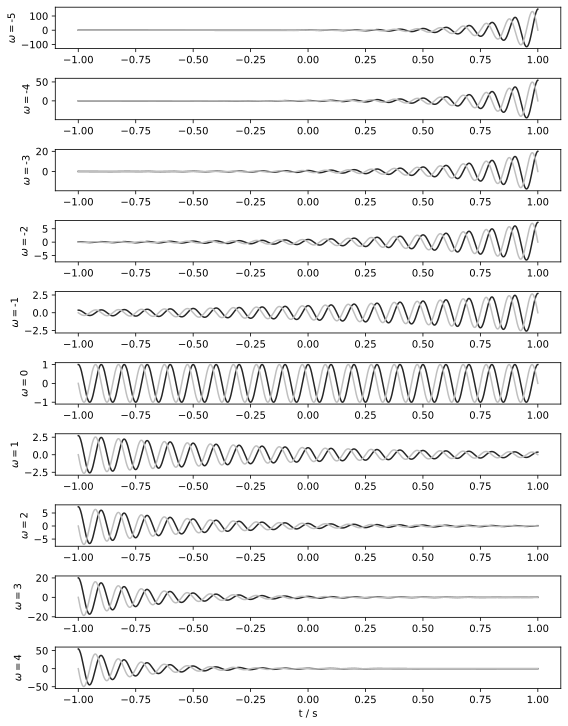

In [31]:
def laplace(t, s, w, r):
        
    out = np.zeros(len(t))
    
    for i in range(len(t)):
        val = t[i]
            
        if r ==1:    
            out[i] = np.real(np.exp(-s*val) * np.exp(-1j * w * val))
        else:
            out[i] = np.imag(np.exp(-s*val) * np.exp(-1j * w * val))
            
    return out



t = np.linspace(-1,1,1000)

fig, axs = plt.subplots(10, 1, figsize=(8, 10))

for i in range(10):    
    
    y = laplace(t,(i-5),2 *np.pi *10,1)  
    axs[i].plot(t,y,color = [0.15,0.15,0.15])
    
    y = laplace(t,(i-5),2 *np.pi *10,0)
    axs[i].plot(t,y, color = [0.75,0.75,0.75])


    axs[i].set_ylabel('$\omega=$'+str(i-5)); 

plt.tight_layout()       
plt.xlabel('t / s')
        
    

## Changing $\sigma$

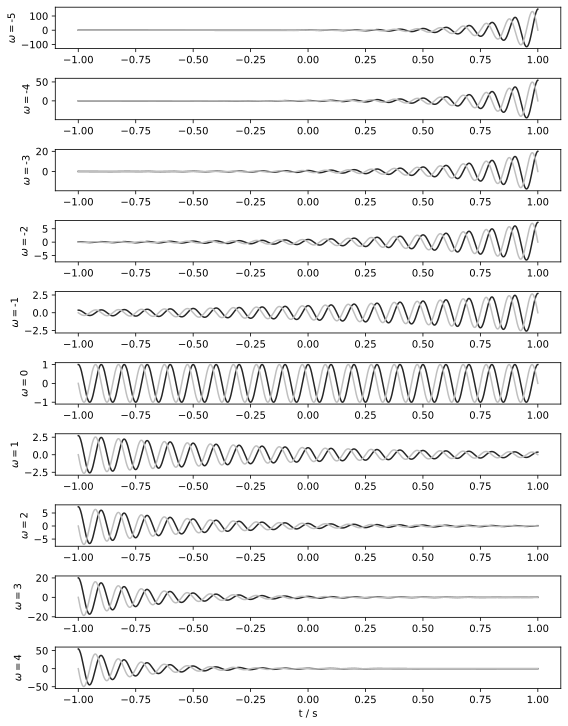

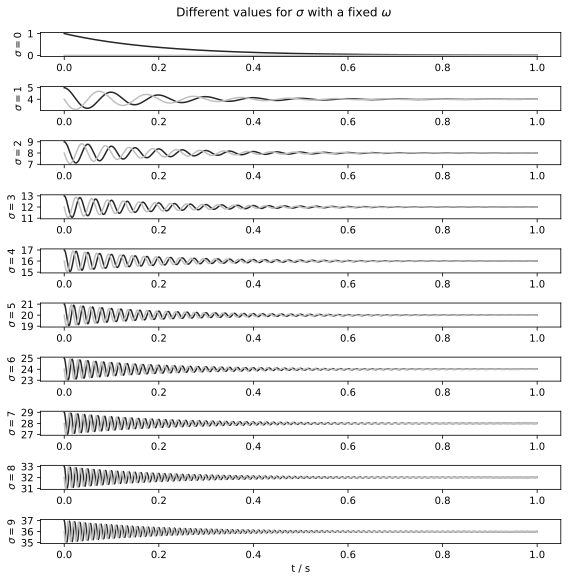

In [ ]:
t = np.linspace(0,1,1000)

fig, axs = plt.subplots(10, 1, figsize=(8, 8))
fig.suptitle('Different values for $\sigma$ with a fixed $\omega$')

for i in range(10):        

    y = laplace(t,5,2 *np.pi *i*10,1) + 4*i
    axs[i].plot(t,y,color = [0.15,0.15,0.15])
    
    y = laplace(t,5,2 *np.pi *i*10,0) + 4*i
    axs[i].plot(t,y, color = [0.75,0.75,0.75])
    axs[i].set_ylabel('$\sigma=$'+str(i)); 


plt.tight_layout()   
plt.xlabel('t / s');
    

----

# The S-Plane

The Laplace transform can be visualized in the S-Plane, in its real and imaginary part.
This represenation shows the stability of the.



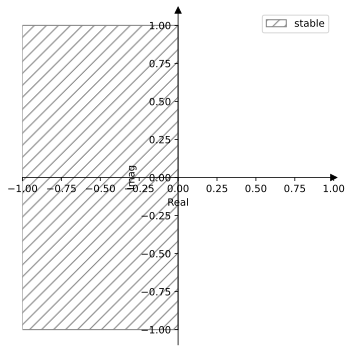

In [27]:
fig, ax = plt.subplots()
# Move the left and bottom spines to x = 0 and y = 0, respectively.
ax.spines[["left", "bottom"]].set_position(("data", 0))
# Hide the top and right spines.
ax.spines[["top", "right"]].set_visible(False)

# Draw arrows (as black triangles: ">k"/"^k") at the end of the axes.  In each
# case, one of the coordinates (0) is a data coordinate (i.e., y = 0 or x = 0,
# respectively) and the other one (1) is an axes coordinate (i.e., at the very
# right/top of the axes).  Also, disable clipping (clip_on=False) as the marker
# actually spills out of the axes.
ax.plot(1, 0, ">k", transform=ax.get_yaxis_transform(), clip_on=False)
ax.plot(0, 1, "^k", transform=ax.get_xaxis_transform(), clip_on=False)

plt.fill_between([-1,0], [1,1],-1 ,color='none',hatch='//',edgecolor="gray",label='stable');

plt.xlim(-1,1)

plt.xlabel('Real')
plt.ylabel('Imag')

plt.legend(loc=1)
plt.show()

## Region of Convergence

-----

## Causality 

## Stability